In [1]:
import pandas as pd
import optbinning as ob
import sklearn as sl
from optbinning import OptimalBinning, BinningProcess
import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
import ydata_profiling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from ydata_profiling import ProfileReport
import category_encoders as ce
import seaborn as sns

*Reading the main dataset*

In [2]:
data = pd.read_csv('D:/my_ML/diploma_polytech/data/raw/vehicle_ins_data_1.csv', sep = ";",index_col= False)
print(data)

           ID Date_start_contract Date_last_renewal Date_next_renewal  \
0           1          05/11/2015        05/11/2015        05/11/2016   
1           1          05/11/2015        05/11/2016        05/11/2017   
2           1          05/11/2015        05/11/2017        05/11/2018   
3           1          05/11/2015        05/11/2018        05/11/2019   
4           2          26/09/2017        26/09/2017        26/09/2018   
...       ...                 ...               ...               ...   
105550  53498          30/07/2018        30/07/2018        30/07/2019   
105551  53499          16/08/2018        16/08/2018        16/08/2019   
105552  53500          21/11/2018        21/11/2018        21/11/2019   
105553  53501          21/11/2018        21/11/2018        21/11/2019   
105554  53502          01/10/2018        01/10/2018        01/10/2019   

        Date_birth Date_driving_licence Distribution_channel  Seniority  \
0       15/04/1956           20/03/1976         

C:\Users\andre\AppData\Local\Temp\ipykernel_18616\2391674371.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('D:/my_ML/diploma_polytech/data/raw/vehicle_ins_data_1.csv', sep = ";",index_col= False)


*Reading alternative dataset*

In [3]:
# data = pd.read_csv('D:/maga_poly/диплом/diploma_polytech/data/raw/motor_data1.csv', index_col= False)
# print(data)

*Data Analysis Main Dataset*

In [3]:
# 1. Первый взгляд на данные
print("Размер датасета:", data.shape)
print("\nПервые 5 строк:")
display(data.head())

print("\nИнформация о данных:")
data.info()

print("\nОсновные статистические характеристики числовых полей:")
display(data.describe())

Размер датасета: (105555, 30)

Первые 5 строк:


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    105555 non-null  int64  
 1   Date_start_contract   105555 non-null  object 
 2   Date_last_renewal     105555 non-null  object 
 3   Date_next_renewal     105555 non-null  object 
 4   Date_birth            105555 non-null  object 
 5   Date_driving_licence  105555 non-null  object 
 6   Distribution_channel  105555 non-null  object 
 7   Seniority             105555 non-null  int64  
 8   Policies_in_force     105555 non-null  int64  
 9   Max_policies          105555 non-null  int64  
 10  Max_products          105555 non-null  int64  
 11  Lapse                 105555 non-null  int64  
 12  Date_lapse            35147 non-null   object 
 13  Payment               105555 non-null  int64  
 14  Premium               105555 n

,ID,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,N_claims_year,...,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,...,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,95226.000000,105555.000000
mean,26271.286789,6.696604,1.455649,1.837232,1.065842,0.221837,0.319180,315.892557,153.557305,0.394695,...,2.721804,0.273895,0.123708,2004.728038,92.682611,1617.759367,18413.657243,4.067898,4.252007,1191.262422
std,15388.309324,6.263911,0.928427,1.155536,0.267807,0.464858,0.466161,140.927969,1477.112362,1.105018,...,0.614835,0.445958,0.329250,6.767037,37.012645,604.697382,9135.074235,1.511839,0.393220,458.081834
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.140000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1950.000000,0.000000,49.000000,270.460000,0.000000,1.978000,43.000000
25%,12925.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,241.610000,0.000000,0.000000,...,3.000000,0.000000,0.000000,2001.000000,75.000000,1390.000000,13127.210000,3.000000,3.999000,1043.000000
50%,26082.000000,4.000000,1.000000,2.000000,1.000000,0.000000,0.000000,292.280000,0.000000,0.000000,...,3.000000,0.000000,0.000000,2005.000000,90.000000,1598.000000,17608.770000,5.000000,4.230000,1205.000000
75%,39754.000000,9.000000,2.000000,2.000000,1.000000,0.000000,1.000000,361.640000,0.000000,0.000000,...,3.000000,1.000000,0.000000,2008.000000,110.000000,1910.000000,22595.000000,5.000000,4.443000,1388.000000
max,53502.000000,40.000000,17.000000,17.000000,4.000000,7.000000,1.000000,2993.340000,260853.240000,25.000000,...,4.000000,1.000000,1.000000,2018.000000,580.000000,7480.000000,220675.800000,6.000000,8.218000,7300.000000


In [6]:
# 2. Анализ пропущенных значений
missing_values = data.isnull().sum()
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Процент пропусков': missing_percent
}).sort_values('Процент пропусков', ascending=False)

print("Анализ пропущенных значений:")
display(missing_df[missing_df['Количество пропусков'] > 0])


Анализ пропущенных значений:


,Количество пропусков,Процент пропусков
Date_lapse,70408,66.702667
Length,10329,9.785420
Type_fuel,1764,1.671167


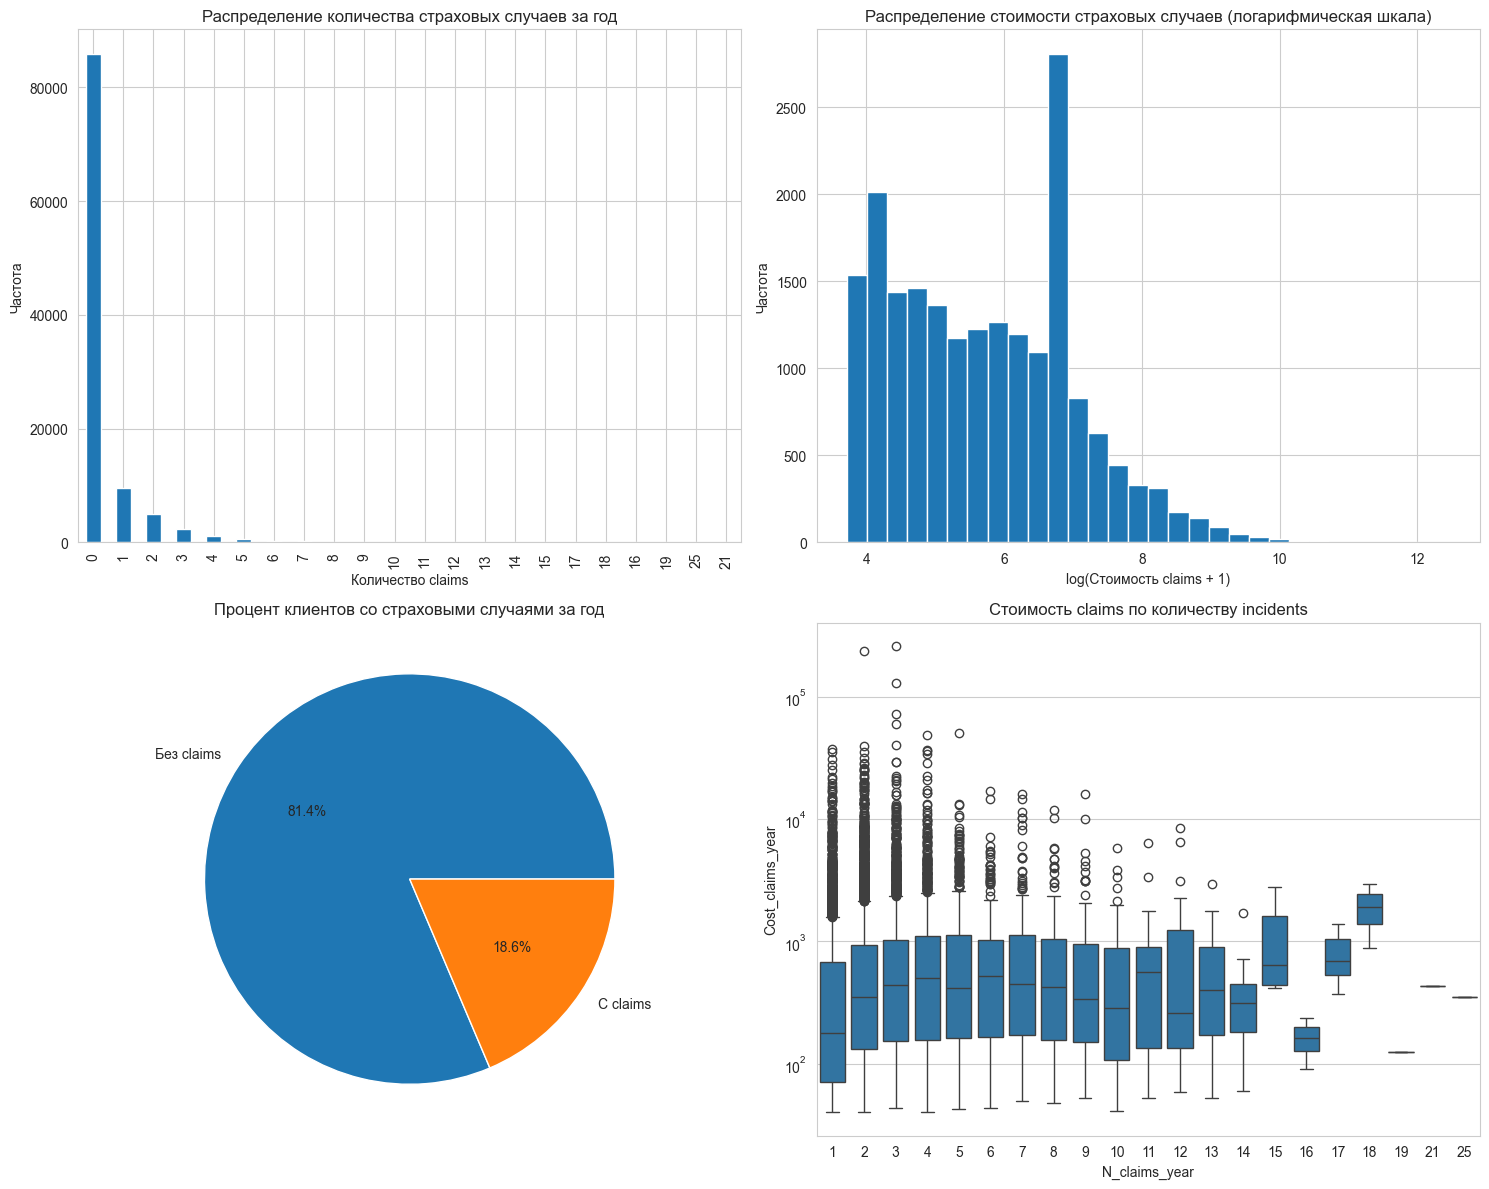

In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
# 3. Анализ целевых переменных
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# Распределение количества страховых случаев за год
data['N_claims_year'].value_counts().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Распределение количества страховых случаев за год')
axes[0, 0].set_xlabel('Количество claims')
axes[0, 0].set_ylabel('Частота')

# Распределение стоимости страховых случаев за год (логарифмическая шкала для лучшей визуализации)
cost_claims = data[data['Cost_claims_year'] > 0]['Cost_claims_year']
axes[0, 1].hist(np.log1p(cost_claims), bins=30)
axes[0, 1].set_title('Распределение стоимости страховых случаев (логарифмическая шкала)')
axes[0, 1].set_xlabel('log(Стоимость claims + 1)')
axes[0, 1].set_ylabel('Частота')

# Соотношение клиентов с claims и без
claim_flag = data['N_claims_year'] > 0
claim_percentage = claim_flag.value_counts(normalize=True) * 100
axes[1, 0].pie(claim_percentage, labels=['Без claims', 'С claims'], autopct='%1.1f%%')
axes[1, 0].set_title('Процент клиентов со страховыми случаями за год')

# Boxplot стоимости claims по количеству incidents
sns.boxplot(x='N_claims_year', y='Cost_claims_year', data=data[data['N_claims_year'] > 0], ax=axes[1, 1])
axes[1, 1].set_title('Стоимость claims по количеству incidents')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()


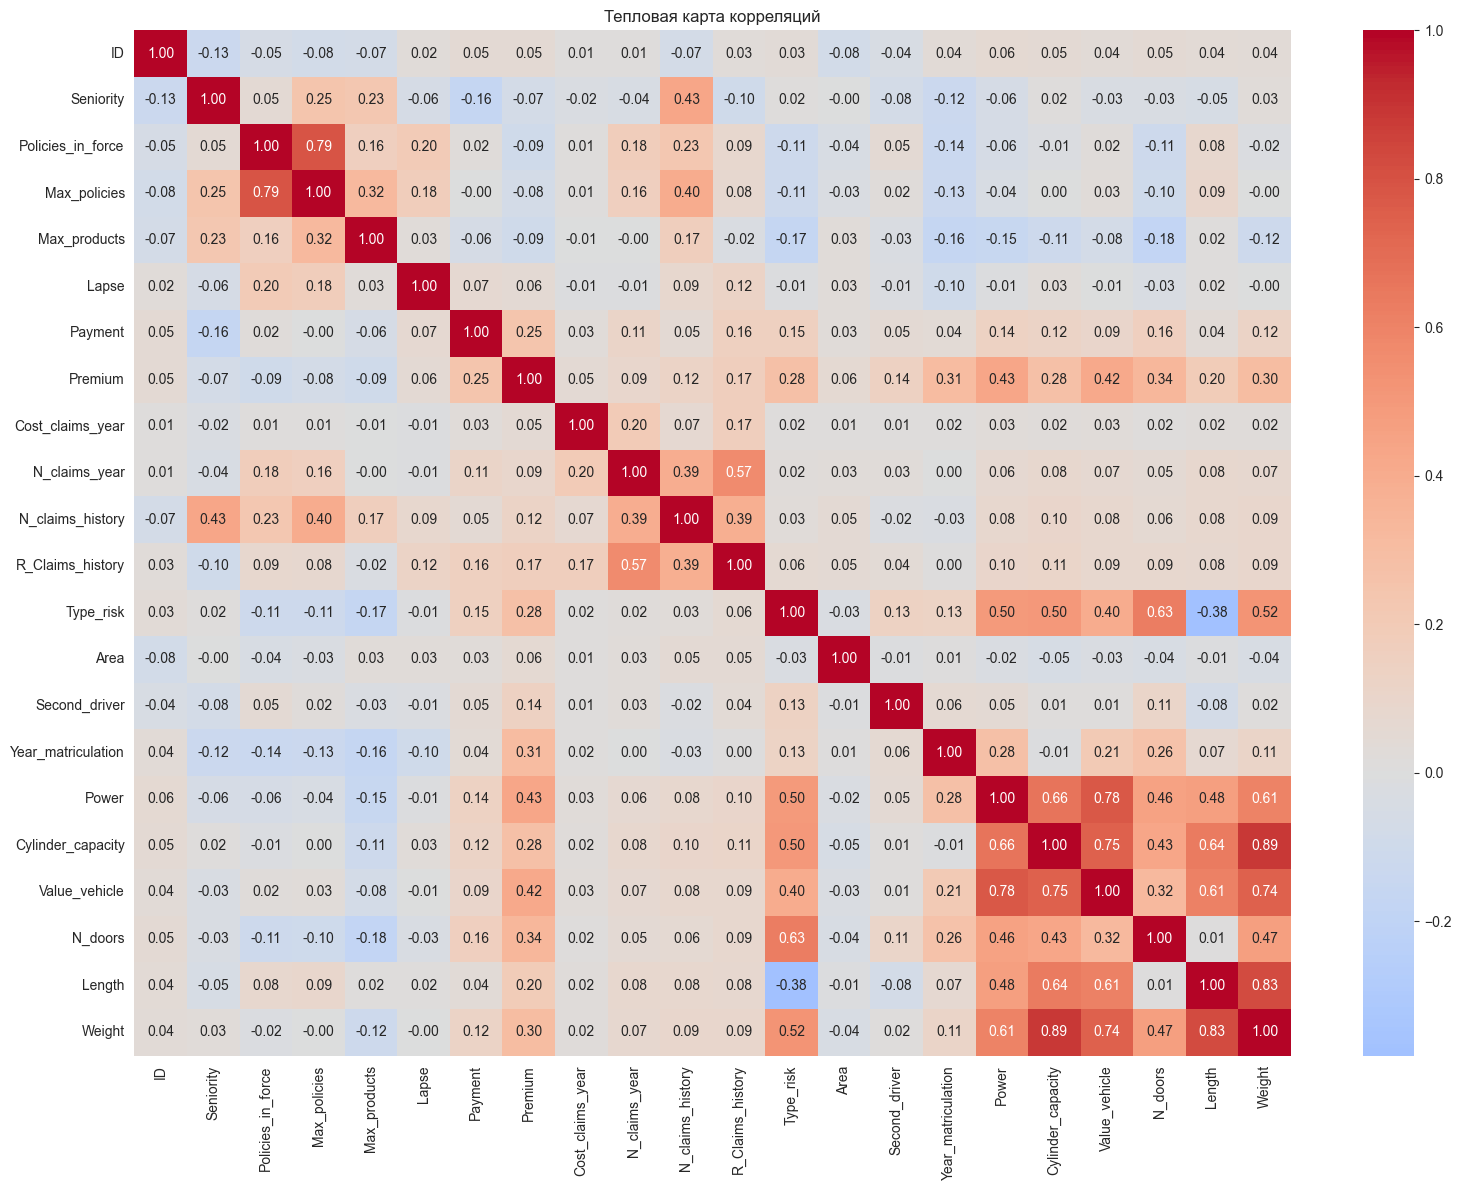

In [5]:
# Создаем корреляционную матрицу только для численных признаков
numerical_df = data.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

# Визуализируем тепловую карту корреляций
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Средние значения признаков по группам (с claims и без):


Has_claim,0,1
ID,26151.059784,26797.021378
Seniority,6.894086,5.833045
Policies_in_force,1.414788,1.634328
Max_policies,1.798287,2.007533
Max_products,1.068014,1.056347
Lapse,0.238147,0.150514
Payment,0.293287,0.432404
Premium,308.762478,347.071319
Cost_claims_year,0.000000,825.040281
N_claims_year,0.000000,2.120635


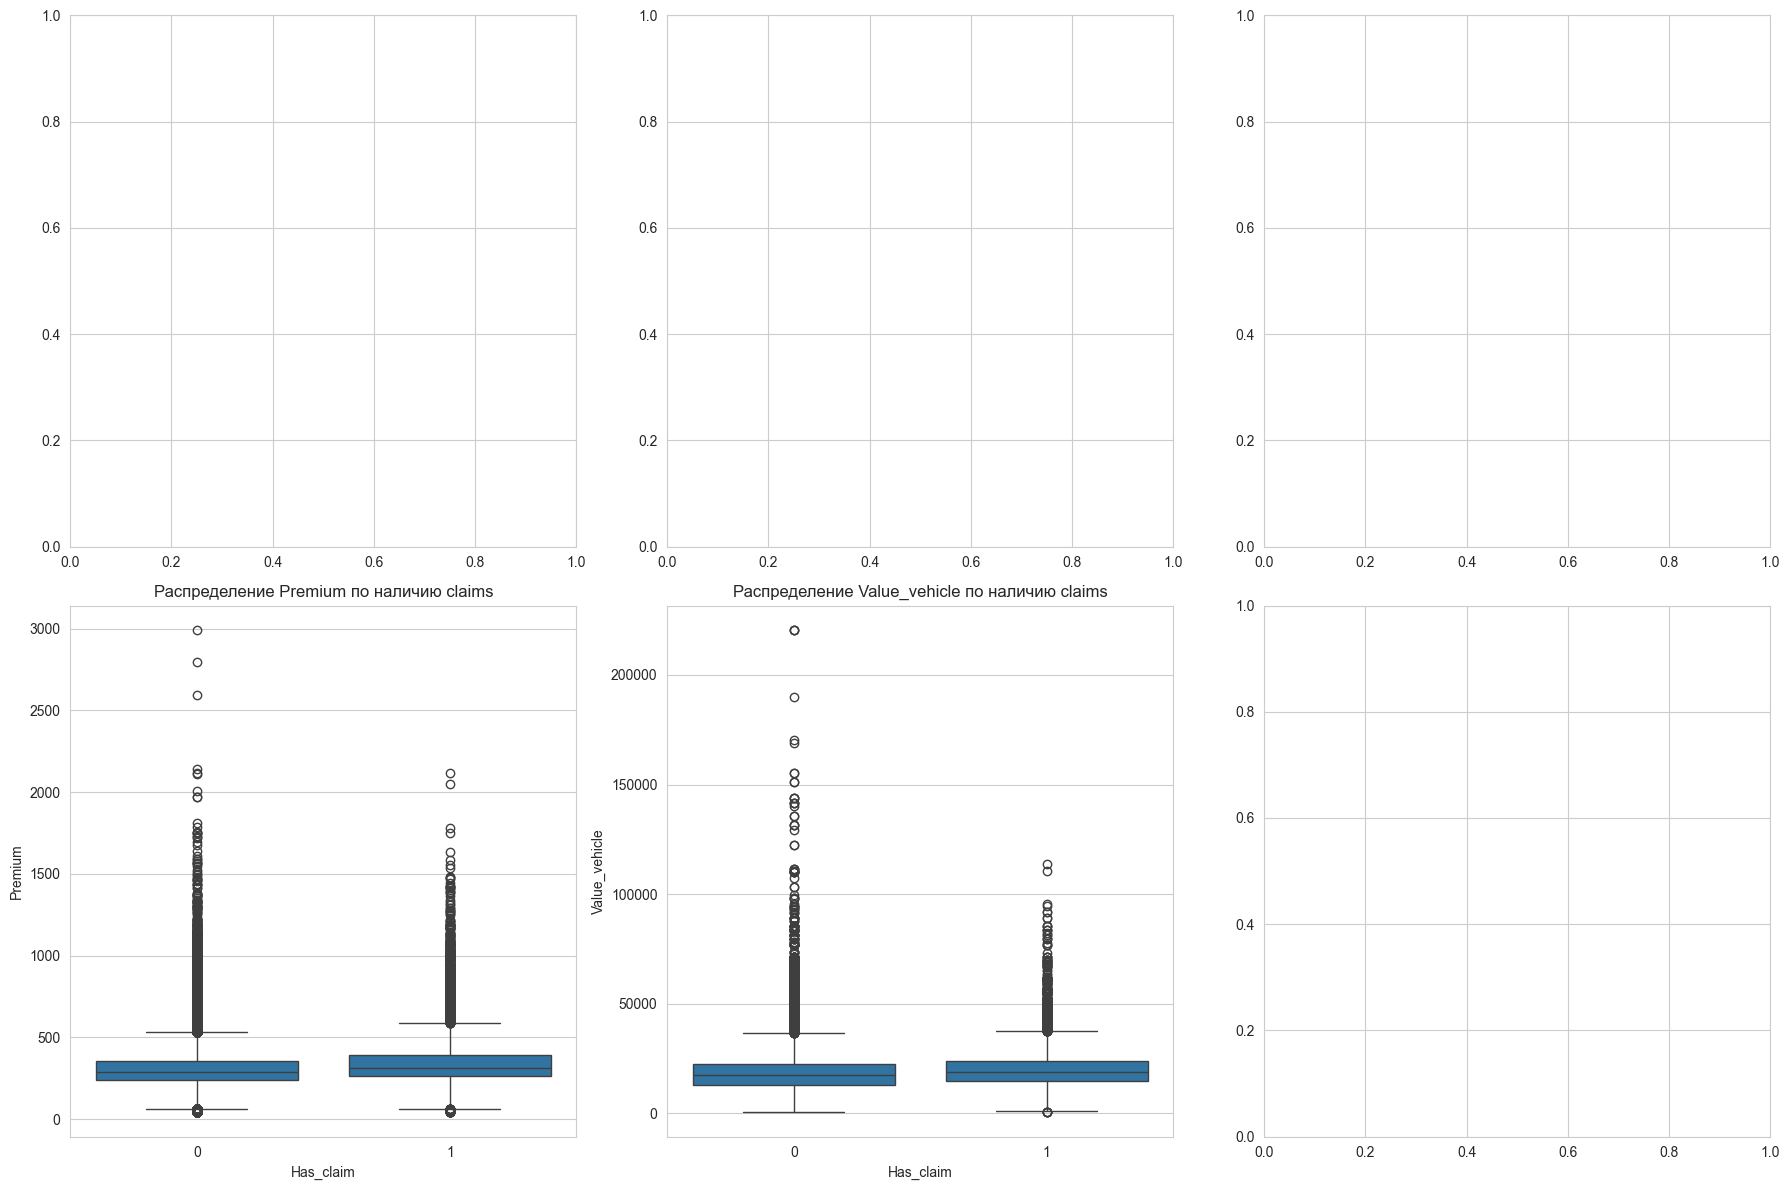

In [6]:
# 8. Анализ связи признаков с целевой переменной
# Создадим бинарную целевую переменную - был ли хотя бы один страховой случай
data['Has_claim'] = (data['N_claims_year'] > 0).astype(int)

# Посмотрим на средние значения признаков для групп с claims и без
claim_summary = data.groupby('Has_claim').mean(numeric_only=True)
print("Средние значения признаков по группам (с claims и без):")
display(claim_summary.T)

# Анализ нескольких ключевых признаков
key_features = ['Age', 'Driving_experience', 'Vehicle_age', 'Premium', 'Value_vehicle']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    if feature in data.columns:
        sns.boxplot(x='Has_claim', y=feature, data=data, ax=axes[i])
        axes[i].set_title(f'Распределение {feature} по наличию claims')

plt.tight_layout()
plt.show()